# Exploring soil modeling in soilice


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl

In [2]:
from soilice.src_soil import MakeDictFloat
from soilice.src_soil import MakeDictArray
from soilice.src_soil import GCEfun
from soilice.src_soil import thetaFun
from soilice.balanceChecks import soilBalanceCheck
from soilice.src_soil import run

In [3]:
# # Overide the KFun with a custom function:
# from numba import jit 
# import soilice.src_soil as sm

# @jit(nopython=True)
# def KFun(psie,psif,pars):
#     thetaL=sm.thetaFun(psif,pars)
#     thetaT=sm.thetaFun(psie,pars)
#     thetaI=1000./918.*(thetaT-thetaL)
        
#     Se=(1+(psie*-pars['alpha'])**pars['n'])**(-pars['m'])
#     Se[psie>0.]=1.0
#     Ke=pars['Ks']*Se**pars['neta']*(1-(1-Se**(1/pars['m']))**pars['m'])**2
    
#     K=Ke*10**(-10*thetaI)
    
#     return K

# sm.KFun=KFun

# # # K=KFun(psif,pars)

# # # K=(KFun(psie,pars)+KFun(psif,pars))/2.

In [4]:
# Soil model options:
opts={}
opts['massflag']=1.              # Solve correct equations (set to zero to remove Cdtheta/dt)
opts['gravity']=1.               # 0. for horizontal; 1. for vertical
opts['cryoflow']=0.              # 0. flow based on psie; 1. flow based on psif 
opts['withadv']=1.               # 0. turn off advection; 1. turn on advection
opts['conductionTop']=0.         # 0. no conduction on upper BC; 1. conduction based on TTop
opts['conductionBot']=0.         # 0. no conduction on lower BC; 1. conduction based on TBot
opts['simulateFlow']=True        # 0. no flow, constant total water content; 1. simulates flow
opts['simulateTransport']=True   # 0. no flow, constant total water content; 1. simulates heat transport
opts['freeDrainage']=1.          # 0. no flow lower BC, 1.0 free draining lowerBC
opts['groundHeatFlux']=0.        # 0. no specified ground heat flux; 1. use specified ground heat flux.

In [5]:
# Import soil parameters:
from soilice.HP_loam import pars

from soilice.thermalSoilParameters import pars as thermalPars
for key in thermalPars: pars[key]=thermalPars[key]

# Import constants:
from soilice.constants import const

# Convert parameter units into days:
pars['Ks']=pars['Ks']*86400
pars['kappa_org']=pars['kappa_org']*86400
pars['kappa_soil']=pars['kappa_soil']*86400
const['kappa_air']=const['kappa_air']*86400
const['kappa_ice']=const['kappa_ice']*86400
const['kappa_liq']=const['kappa_liq']*86400

In [6]:
# Space grid
nz=160
dz=np.zeros(nz)+0.05
bz=np.hstack([0, np.cumsum(dz)])
z=(bz[:-1]+bz[1:])/2.
zMax=bz[-1]

# Time grid
t=np.arange(0,100,1) # days
nt=len(t)
dt=t[1]-t[0]

In [7]:
# Upper boundary condition - mass and heat fluxes:
qI=np.zeros(nt)+0.05
TTop=np.zeros(nt) # Temperature boundary for conduction
TBot=np.zeros(nt) #
TInf=np.zeros(nt)+0. # Temperature of infiltrating water
jTopBC=np.zeros(nt) # Specified ground heat flux, if used.

In [8]:
# Distribute parameters by layer:

# This way we have one unique parameter for each depth, which is assigned in this loop.
# Here I am just making them all the same, so this part of the code would need to be modified:
# parsD=MakeDictArray()
# for key in pars:
#     parsD[key]=np.zeros(nz)+pars[key]

# # For a uniform simulation, just run this code unmodified. This is more efficient:
parsD=MakeDictFloat()
for k in pars: parsD[k]=pars[k]

In [9]:
def makePlot():
    pl.figure(figsize=(10,4))
    # pl.plot(thetaL.T-pars['thetaR'],z,'b')
    pl.subplot(1,3,1)
    pl.plot(T.T,z)
    pl.ylim(zMax,0); pl.grid('on')
    pl.ylabel('Depth (m)')
    pl.xlabel(r'$T$')
    pl.subplot(1,3,2)
    pl.plot(thetaL[0,:].T,z,'-r')
    pl.plot(thetaI[0,:].T+thetaL[0,:].T,z,'--b')
    pl.plot(thetaI[0,:].T,z,'--k')
    pl.plot(thetaL[1:,:].T,z,'-r')
    pl.plot(thetaI[1:,:].T+thetaL[1:,:].T,z,'--b')
    pl.plot(thetaI[1:,:].T,z,'--k')
    pl.legend(['liquid','total','ice'])
    pl.ylim(zMax,0); pl.grid('on')
    pl.xlabel(r'$\theta$')
    pl.subplot(1,3,3)
    pl.plot(psie.T,z)
    pl.ylim(zMax,0); pl.grid('on')
    pl.xlabel(r'$\psi_e$')

ode, with jac runtime = 3.54 seconds


Text(0.5, 1.0, 'Initial T = 0 deg C')

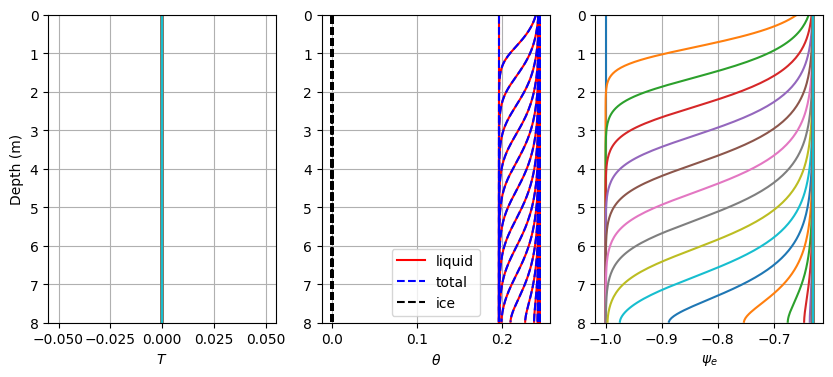

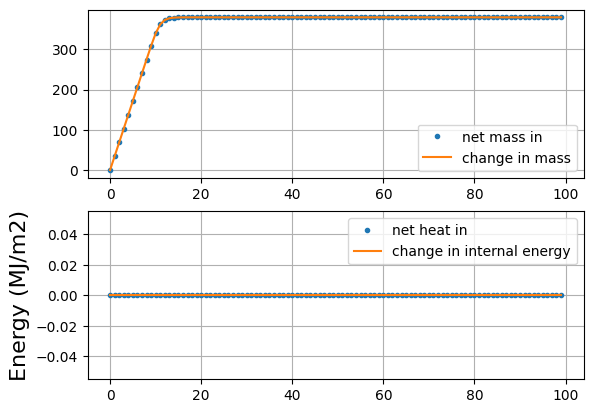

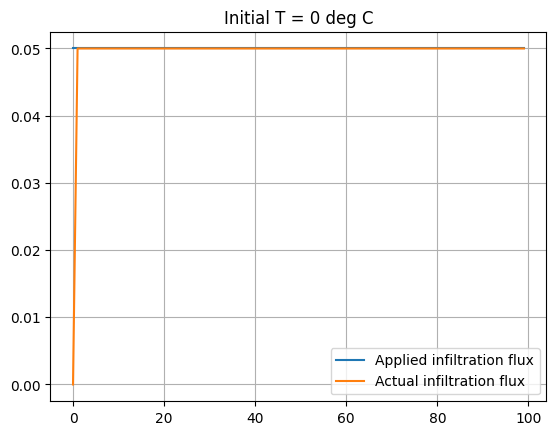

In [10]:
# Run the model:
# Initial condition
T0=np.linspace(0,0,nz)
psi0=np.linspace(-1,-1,nz) # z-zMax 
psie,T,thetaL,thetaI,qT,qB,jT,jB=run(dt,t,dz,nz,T0,psi0,qI,TTop,TBot,TInf,jTopBC,parsD,const,opts,rtol=1e-8)
makePlot()
soilBalanceCheck(t,thetaL,thetaI,T,qT,qB,jT,jB,dz,const,pars)

pl.figure()
pl.plot(t,qI,label='Applied infiltration flux')
pl.plot(t,qT,label='Actual infiltration flux')
pl.legend(); pl.grid()
pl.title('Initial T = 0 deg C')

ode, with jac runtime = 0.39 seconds


Text(0.5, 1.0, 'Initial T = -0.1 deg C')

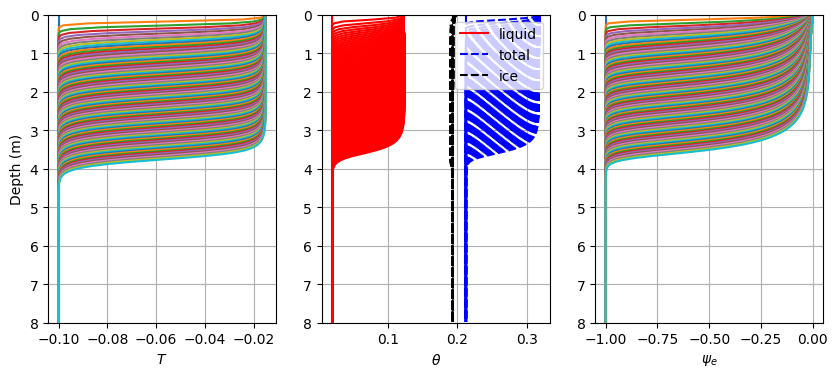

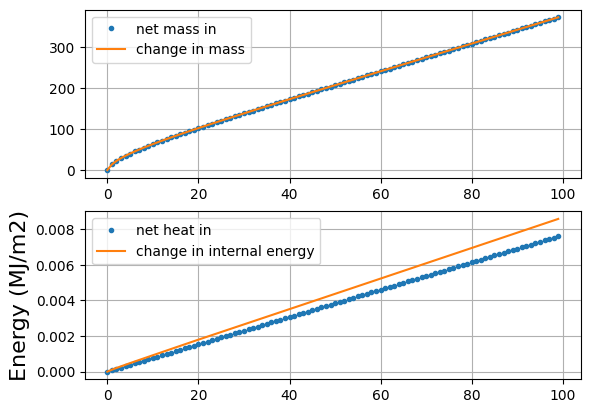

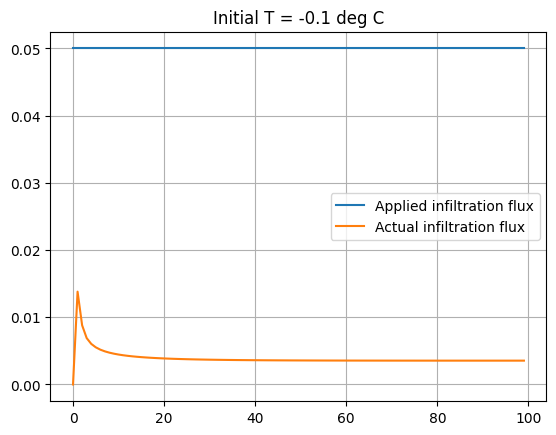

In [11]:
# Run the model:
# Initial condition
T0=np.linspace(-0.1,-0.1,nz)
psi0=np.linspace(-1,-1,nz) # z-zMax 
psie,T,thetaL,thetaI,qT,qB,jT,jB=run(dt,t,dz,nz,T0,psi0,qI,TTop,TBot,TInf,jTopBC,parsD,const,opts,rtol=1e-8)
makePlot()
soilBalanceCheck(t,thetaL,thetaI,T,qT,qB,jT,jB,dz,const,pars)

pl.figure()
pl.plot(t,qI,label='Applied infiltration flux')
pl.plot(t,qT,label='Actual infiltration flux')
pl.legend(); pl.grid()
pl.title('Initial T = -0.1 deg C')

In [12]:
qT

array([0.        , 0.01381414, 0.00880495, 0.00690253, 0.00604199,
       0.00552841, 0.00518062, 0.00492705, 0.00473298, 0.00457924,
       0.00445428, 0.00435069, 0.00426344, 0.004189  , 0.00412482,
       0.00406899, 0.00402005, 0.00397687, 0.00393856, 0.0039044 ,
       0.00387381, 0.00384631, 0.00382151, 0.00379907, 0.00377871,
       0.00376019, 0.00374332, 0.00372792, 0.00371382, 0.00370091,
       0.00368905, 0.00367817, 0.00366815, 0.00365892, 0.00365042,
       0.00364257, 0.00363532, 0.00362862, 0.00362243, 0.0036167 ,
       0.00361139, 0.00360647, 0.00360192, 0.0035977 , 0.00359378,
       0.00359015, 0.00358678, 0.00358366, 0.00358076, 0.00357807,
       0.00357557, 0.00357325, 0.0035711 , 0.0035691 , 0.00356725,
       0.00356553, 0.00356393, 0.00356245, 0.00356108, 0.00355981,
       0.00355864, 0.00355755, 0.00355654, 0.00355561, 0.00355475,
       0.00355395, 0.00355322, 0.00355255, 0.00355192, 0.00355135,
       0.00355083, 0.00355034, 0.0035499 , 0.0035495 , 0.00354

ode, with jac runtime = 0.35 seconds


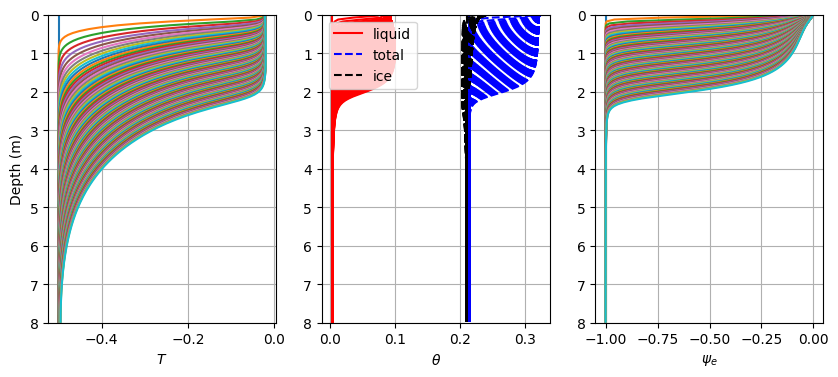

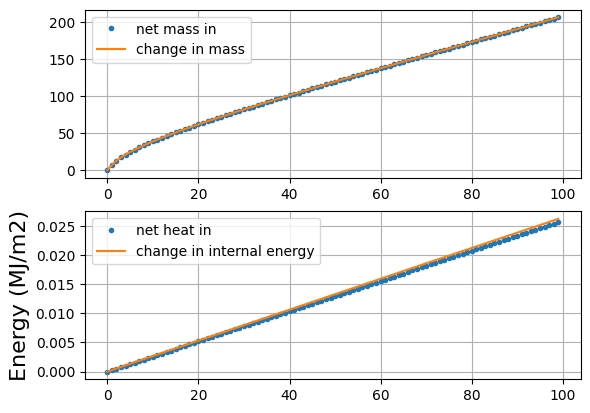

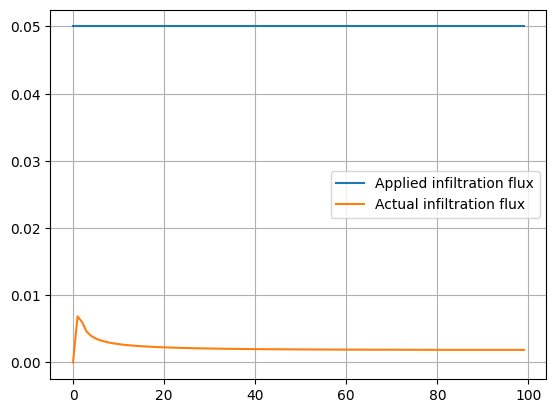

In [13]:
# Run the model:
# Initial condition
T0=np.linspace(-0.50,-0.50,nz)
psi0=np.linspace(-1,-1,nz) # z-zMax 
psie,T,thetaL,thetaI,qT,qB,jT,jB=run(dt,t,dz,nz,T0,psi0,qI,TTop,TBot,TInf,jTopBC,parsD,const,opts,rtol=1e-8)
makePlot()
soilBalanceCheck(t,thetaL,thetaI,T,qT,qB,jT,jB,dz,const,pars)
pl.figure()
pl.plot(t,qI,label='Applied infiltration flux')
pl.plot(t,qT,label='Actual infiltration flux')
pl.legend(); pl.grid()

ode, with jac runtime = 0.32 seconds


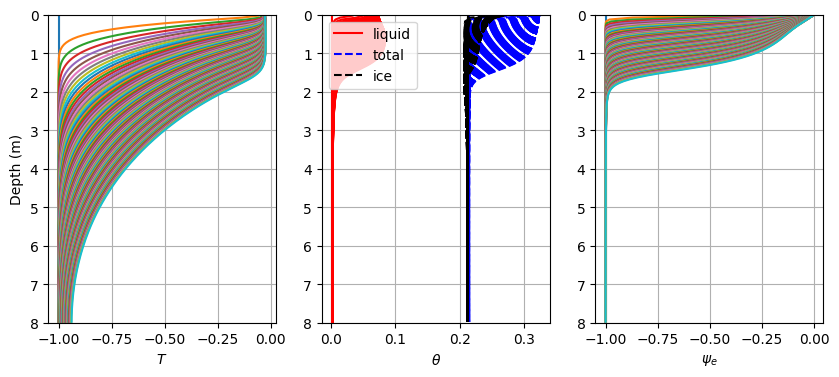

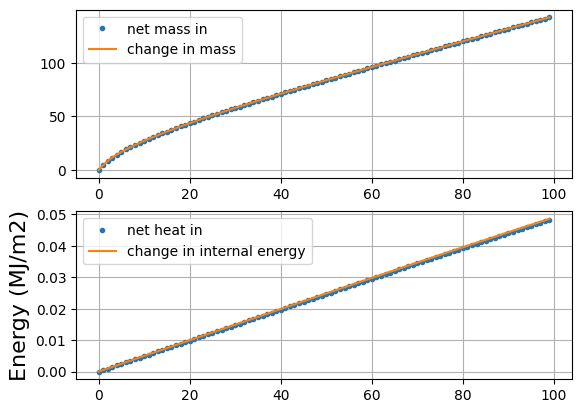

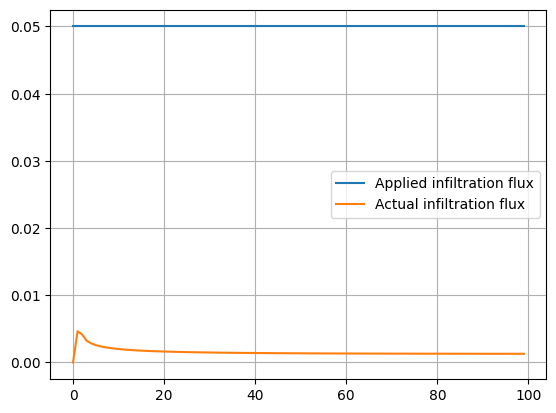

In [14]:
# Run the model:
# Initial condition
T0=np.linspace(-1,-1,nz)
psi0=np.linspace(-1,-1,nz) # z-zMax 
psie,T,thetaL,thetaI,qT,qB,jT,jB=run(dt,t,dz,nz,T0,psi0,qI,TTop,TBot,TInf,jTopBC,parsD,const,opts,rtol=1e-8)
makePlot()
soilBalanceCheck(t,thetaL,thetaI,T,qT,qB,jT,jB,dz,const,pars)
pl.figure()
pl.plot(t,qI,label='Applied infiltration flux')
pl.plot(t,qT,label='Actual infiltration flux')
pl.legend(); pl.grid()

ode, with jac runtime = 0.31 seconds


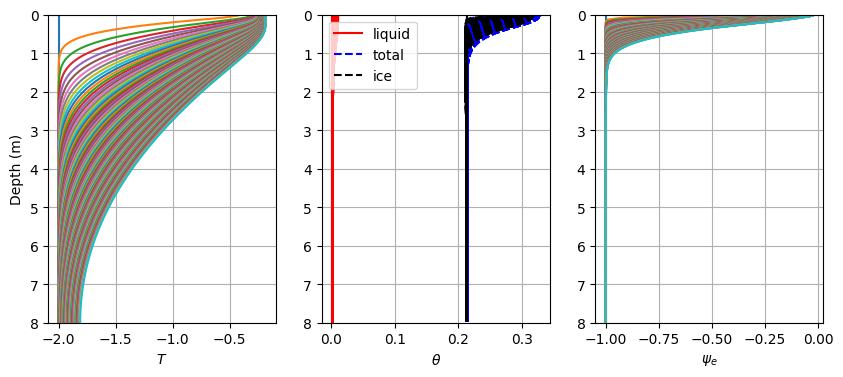

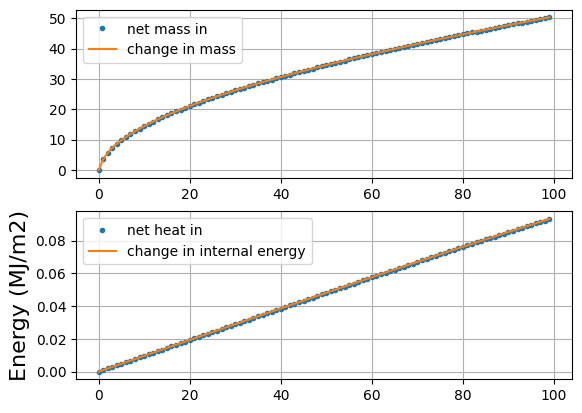

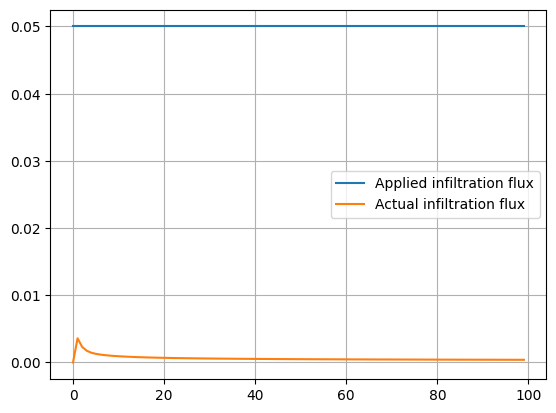

In [15]:
# Run the model:
# Initial condition
T0=np.linspace(-2,-2,nz)
psi0=np.linspace(-1,-1,nz) # z-zMax 
psie,T,thetaL,thetaI,qT,qB,jT,jB=run(dt,t,dz,nz,T0,psi0,qI,TTop,TBot,TInf,jTopBC,parsD,const,opts,rtol=1e-8)
makePlot()
soilBalanceCheck(t,thetaL,thetaI,T,qT,qB,jT,jB,dz,const,pars)

pl.figure()
pl.plot(t,qI,label='Applied infiltration flux')
pl.plot(t,qT,label='Actual infiltration flux')
pl.legend(); pl.grid()

ode, with jac runtime = 0.30 seconds


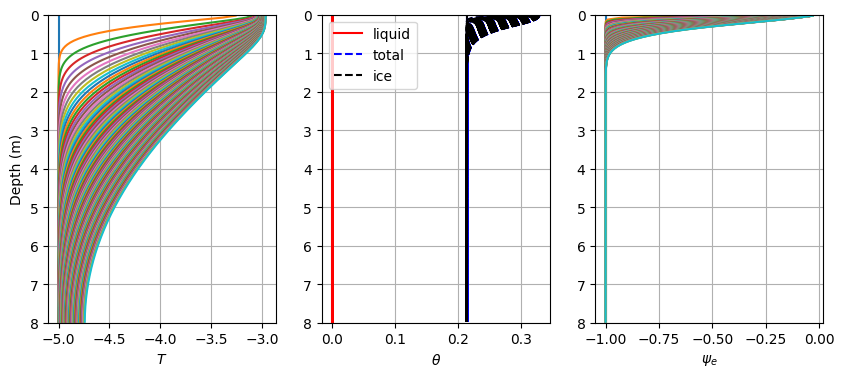

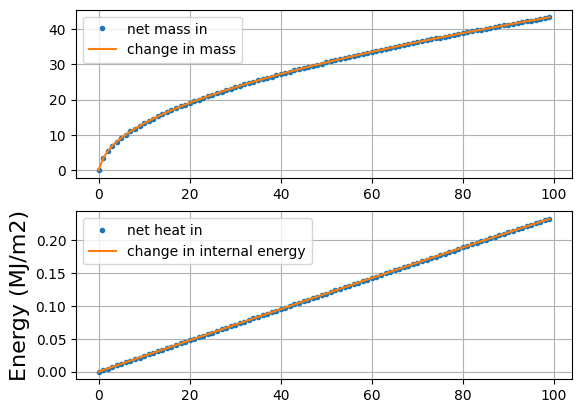

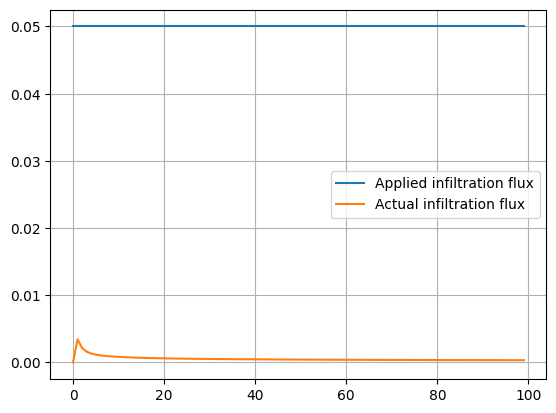

In [16]:
# Run the model:
# Initial condition
T0=np.linspace(-5,-5,nz)
psi0=np.linspace(-1,-1,nz) # z-zMax 
psie,T,thetaL,thetaI,qT,qB,jT,jB=run(dt,t,dz,nz,T0,psi0,qI,TTop,TBot,TInf,jTopBC,parsD,const,opts,rtol=1e-8)
makePlot()
soilBalanceCheck(t,thetaL,thetaI,T,qT,qB,jT,jB,dz,const,pars)

pl.figure()
pl.plot(t,qI,label='Applied infiltration flux')
pl.plot(t,qT,label='Actual infiltration flux')
pl.legend(); pl.grid()